In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

## Examples Cells

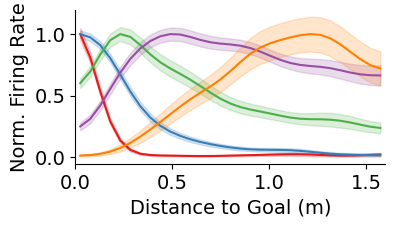

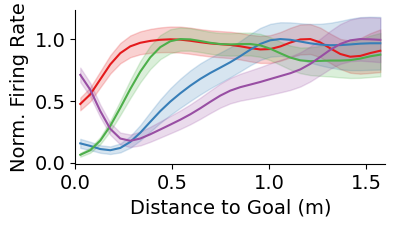

In [51]:
# plot some individual units
from GridMaze.analysis.cluster_tuning import distance_to_goal as dtg
from GridMaze.analysis.core import get_clusters as gc
import numpy as np
from cmap import Colormap

reload(dtg)
reload(gc)

example_clusters = [
    "m2.2022-07-03.maze_cluster43",
    "m3.2022-07-02.maze_cluster44",
    "m2.2022-07-03.maze_cluster9",
    "m7.2022-07-02.maze_cluster55",
    "m7.2022-07-25.maze_cluster73",
]

other_example_clusters = [
    "m7.2022-07-10.maze_cluster8",
    "m2.2022-07-13.maze_cluster19",
    "m2.2022-07-13.maze_cluster86",
    "m7.2022-07-10.maze_cluster53",
]


def plot_example_neurons(clusters, ax, cmap="hls"):
    cm = Colormap(cmap)
    colors = cm(np.linspace(0, 1, len(clusters)))
    for cluster, c in zip(clusters, colors):
        Cluster = gc.get_cluster(cluster)
        Cluster.plot_tuning(feature="distance_to_goal", feature_kwargs={"normalisation": "max", "color": c}, ax=ax)
    ax.set_xlabel("Distance to Goal (m)")
    ax.set_ylabel("Norm. Firing Rate")
    return


f1, ax = plt.subplots(1, 1, figsize=(4, 2))
plot_example_neurons(example_clusters, ax, cmap="colorbrewer:set1_5")
f1.savefig("../results/distance_to_goal/figures/main/example_neurons_1.pdf")

f2, ax = plt.subplots(1, 1, figsize=(4, 2))
plot_example_neurons(other_example_clusters, ax, cmap="colorbrewer:set1_4")
f2.savefig("../results/distance_to_goal/figures/main/example_neurons_2.pdf")

## Population Tuning

In [9]:
from GridMaze.analysis.distance_to_goal import population_tuning as pt

In [10]:
# get data to plot distance tuning heatmaps
population_tuning_df = pt.get_population_tuning_df(late_sessions=False)

frames.navigation.parquet not found for m3.2022-06-25.maze
frames.spikeRates.parquet not found for m3.2022-06-25.maze
clusters.metrics.htsv not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


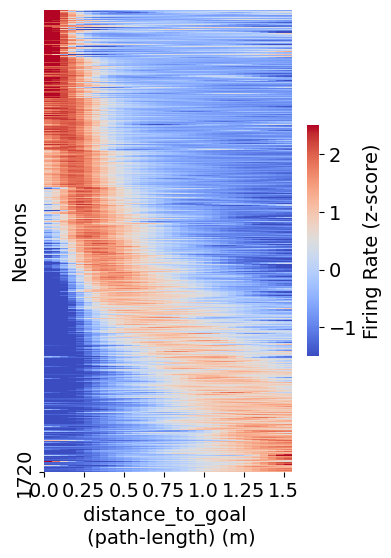

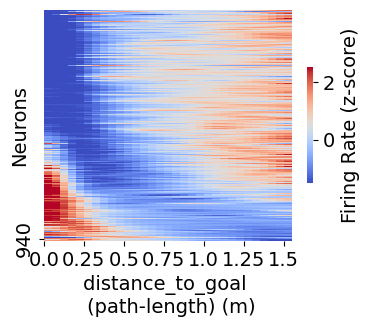

In [26]:
f1, ax = plt.subplots(1, 1, figsize=(4, 6))
reload(pt)
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="pos", ax=ax, cmap="coolwarm", v_range=(-1.5, 2.5))
f1.savefig("../results/distance_to_goal/figures/main/heatmap_1.pdf")

f2, ax = plt.subplots(1, 1, figsize=(4, 3))
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="neg", ax=ax, cmap="coolwarm", v_range=(-1.5, 2.5))
f2.savefig("../results/distance_to_goal/figures/main/heatmap_2.pdf")

## What distance metric best fits the data?

In [3]:
from GridMaze.analysis.distance_to_goal import distance_metrics as dm

cpd_summary_df = dm.get_distance_metric_CPD_summary_df(subfolder="all_trials")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: 
 t-stat: 4.280, p-value: 0.008


(-0.4, 2.0)

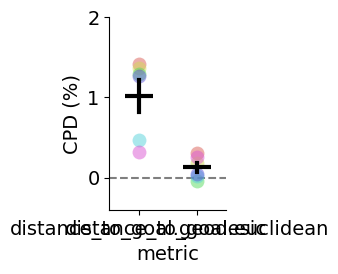

In [ ]:
reload(dm)
f, ax = plt.subplots(1, 1, figsize=(1.5, 2.5))
dm.plot_cross_subject_CPD_comparison(
    cpd_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    maze_names=["maze_1", "maze_2"],
    late_sessions=True,
    ax=ax,
)
ax.set_ylim(-0.4, 2.0)
# f.savefig("../results/distance_to_goal/figures/main/cpd_comparison.pdf")

## Tunning curves are best fit to a family of gamma distributions (not gaussian)

In [39]:
fit_summary_df = pt.get_tuning_fits_summary_df(late_sessions=False)

clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


gamma_4p vs gaussian_4p: 
 t-stat: 7.322, p-value: 7.447e-04


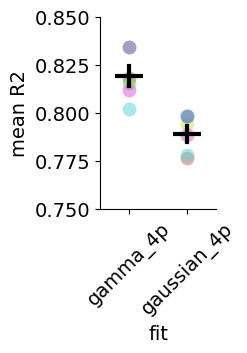

In [50]:
reload(pt)
f, ax = plt.subplots(1, 1, figsize=(1.5, 2.5))
pt.plot_cross_subject_curve_fit_comparison(fit_summary_df, curve_fits=["gamma_4p", "gaussian_4p"], ax=ax)
ax.set_ylim(0.75, 0.85)
f.savefig("../results/distance_to_goal/figures/main/gamma_vs_gaussian.pdf")

## Decoding distance to goal

In [69]:
# get distance to goal decoding results
# what can we read out from these tuning curves? how good is the distance decoding at longer distances
from GridMaze.analysis.distance_to_goal import logreg_decoder as ld

results_df = ld.load_decoding_results(subfolder="all_dist")

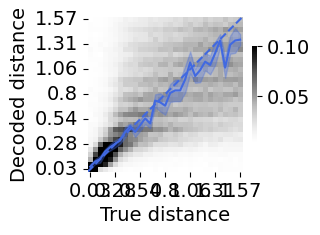

In [72]:
reload(ld)
f, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
ld.plot_distance_decoding_probs(results_df, moving_only=True, ax=ax)
f.savefig("../results/distance_to_goal/figures/main/distance_decoding.pdf")

# Supplementary Materials

In [41]:
# we can also look at the difference between weights (L1_ratio) between distance metrics in the regression
# with optimised regularisation
L1_ratio_summary_df = dm.get_L1_ratio_summary_df("all_trials")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: L1_ratio t-stat: 3.845, p-value: 0.012


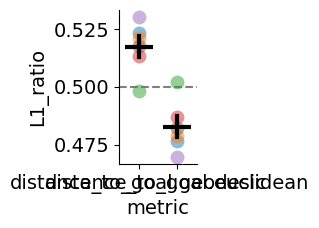

In [75]:
f, ax = plt.subplots(1, 1, figsize=(1, 2))
dm.plot_cross_subject_weight_comparison(
    L1_ratio_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    norm_metric="L1_ratio",
    late_sessions=True,
    maze_names=["maze_1", "maze_2"],
    ax=ax,
    print_stats=True,
)
f.savefig("../results/distance_to_goal/figures/supp/L1_ratio_comparison.pdf")

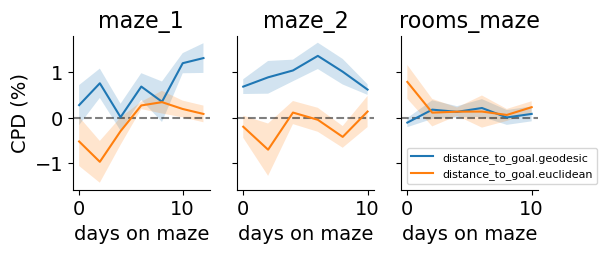

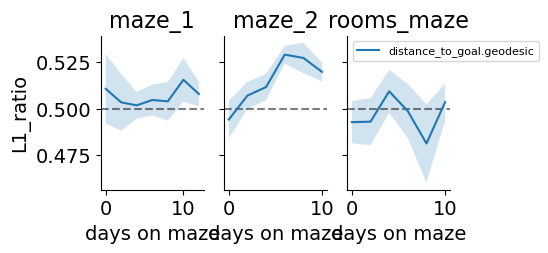

In [76]:
# we can visualise the CPD and L1_ratio comparisons across learning and across mazes
reload(dm)
f1, axes = plt.subplots(1, 3, figsize=(6, 2), sharey=True)
dm.plot_CPD_timeseries(
    cpd_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    axes=axes,
    group_days=2,
)
f1.savefig("../results/distance_to_goal/figures/supp/cpd_timeseries.pdf")

f2, axes = plt.subplots(1, 3, figsize=(4.5, 2), sharey=True)
dm.plot_weights_comparison_timeseries(
    L1_ratio_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    plot_metric="distance_to_goal.geodesic",
    group_days=2,
    axes=axes,
)
f2.savefig("../results/distance_to_goal/figures/supp/L1_ratio_timeseries.pdf")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: 
 t-stat: 4.280, p-value: 0.008
distance_to_goal.geodesic_vs_distance_to_goal.manhattan: 
 t-stat: 3.935, p-value: 0.011
distance_to_goal.geodesic_vs_distance_to_goal.future: 
 t-stat: 5.521, p-value: 0.003
distance_to_goal.geodesic_vs_progress_to_goal.path_length: 
 t-stat: 4.028, p-value: 0.010
distance_to_goal.geodesic_vs_progress_to_goal.time: 
 t-stat: 5.069, p-value: 0.004
distance_to_goal.euclidean_vs_distance_to_goal.manhattan: 
 t-stat: 3.237, p-value: 0.023
distance_to_goal.euclidean_vs_distance_to_goal.future: 
 t-stat: -4.005, p-value: 0.010
distance_to_goal.euclidean_vs_progress_to_goal.path_length: 
 t-stat: 3.003, p-value: 0.030
distance_to_goal.euclidean_vs_progress_to_goal.time: 
 t-stat: 5.306, p-value: 0.003
distance_to_goal.manhattan_vs_distance_to_goal.future: 
 t-stat: -3.734, p-value: 0.014
distance_to_goal.manhattan_vs_progress_to_goal.path_length: 
 t-stat: 3.243, p-value: 0.023
distance_to_goal.manhattan

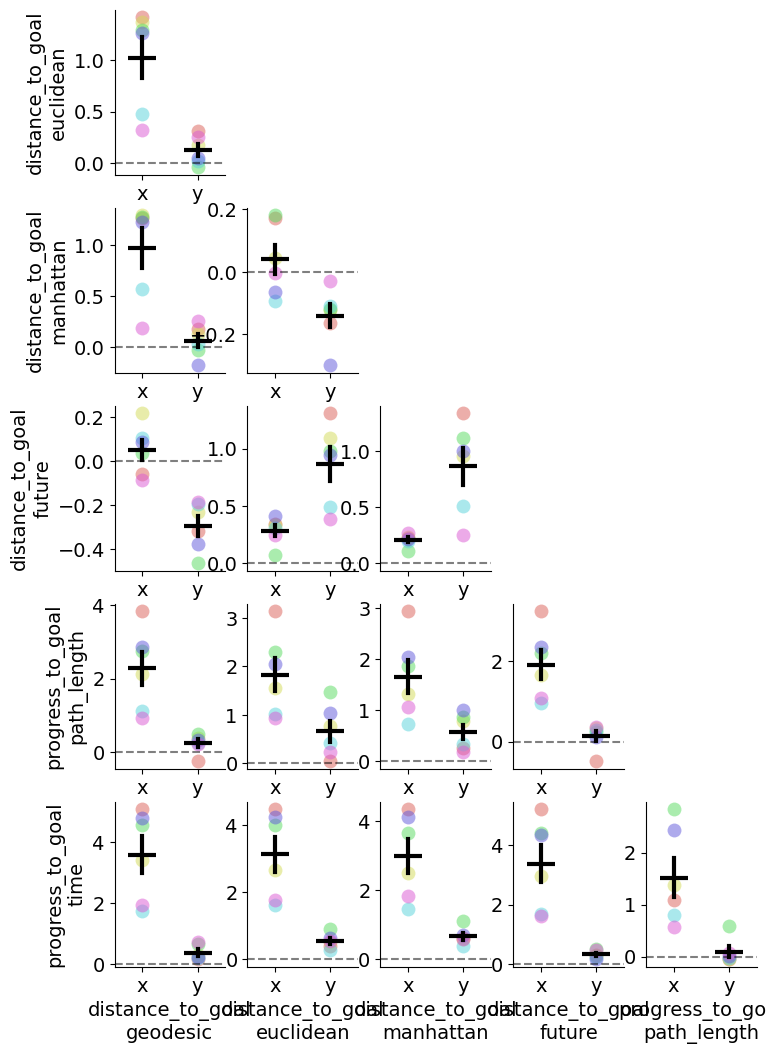

In [10]:
# more thorough comparison of different distance & progress to goal metrics for those interested
reload(dm)
f, axes = plt.subplots(6, 6, figsize=(10, 15))
dm.plot_pairwise_CPD_cross_subject_comparisons(cpd_summary_df, axes=axes)
f.savefig("../results/distance_to_goal/figures/supp/pairwise_CPD_comparisons.pdf")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: L1_ratio t-stat: 3.845, p-value: 0.012
distance_to_goal.geodesic_vs_distance_to_goal.manhattan: L1_ratio t-stat: 4.974, p-value: 0.004
distance_to_goal.geodesic_vs_distance_to_goal.future: L1_ratio t-stat: 6.775, p-value: 0.001
distance_to_goal.geodesic_vs_progress_to_goal.path_length: L1_ratio t-stat: 7.145, p-value: 0.001
distance_to_goal.geodesic_vs_progress_to_goal.time: L1_ratio t-stat: 11.637, p-value: 0.000
distance_to_goal.euclidean_vs_distance_to_goal.manhattan: L1_ratio t-stat: -0.849, p-value: 0.435
distance_to_goal.euclidean_vs_distance_to_goal.future: L1_ratio t-stat: 2.590, p-value: 0.049
distance_to_goal.euclidean_vs_progress_to_goal.path_length: L1_ratio t-stat: 5.574, p-value: 0.003
distance_to_goal.euclidean_vs_progress_to_goal.time: L1_ratio t-stat: 10.348, p-value: 0.000
distance_to_goal.manhattan_vs_distance_to_goal.future: L1_ratio t-stat: 3.319, p-value: 0.021
distance_to_goal.manhattan_vs_progress_to_goal.

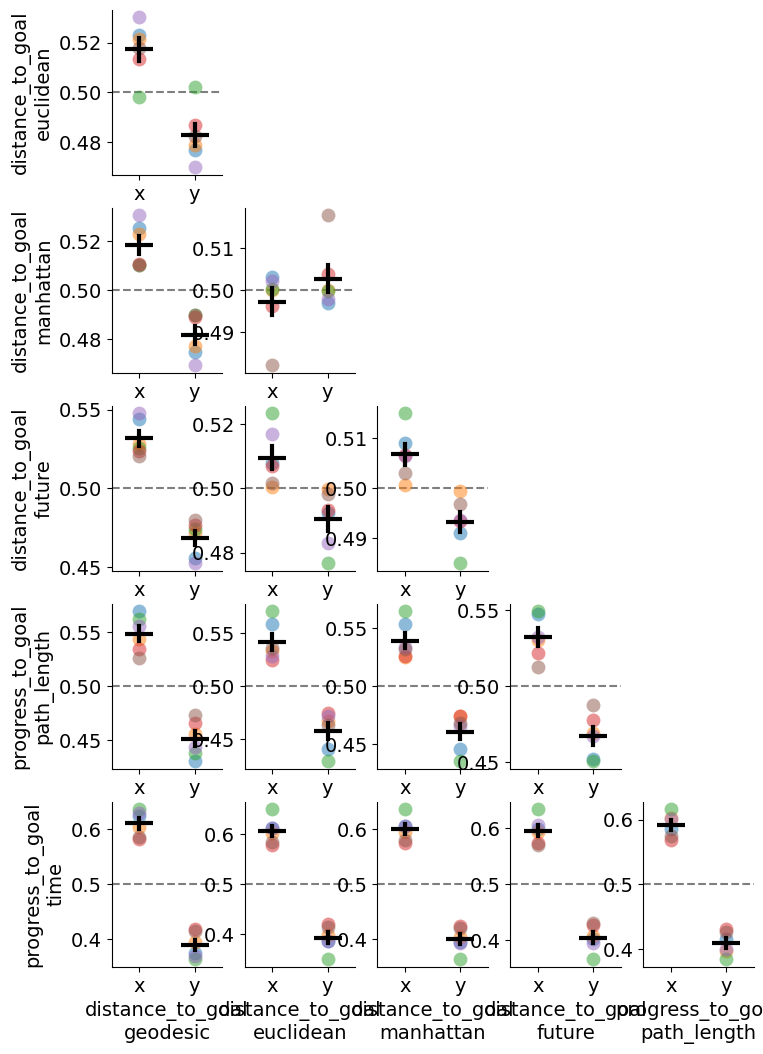

In [ ]:
# we can also compare distance metrics in a different way, L1_ratio between metrics in the regression
reload(dm)
f, axes = plt.subplots(6, 6, figsize=(10, 15))
dm.plot_all_cross_subject_weight_comparisons(L1_ratio_summary_df, axes=axes)
f.savefig("../results/distance_to_goal/figures/supp/pairwise_L1_ratio_comparisons.pdf")

## Visualise quantiles of the distance to goal tuning heatmap

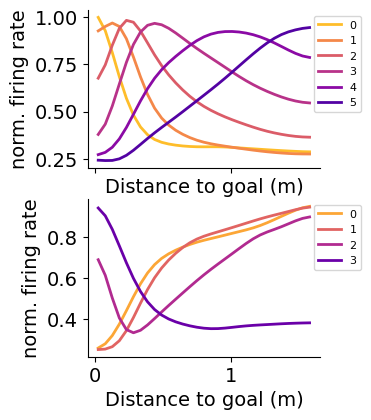

In [86]:
reload(pt)
f, axes = plt.subplots(2, 1, figsize=(3, 4.5), sharex=True)
pt.plot_population_quantiles(population_tuning_df, sign="pos", normalisation_method="max", n_quantiles=6, ax=axes[0])
pt.plot_population_quantiles(population_tuning_df, sign="neg", normalisation_method="max", n_quantiles=4, ax=axes[1])
f.savefig("../results/distance_to_goal/figures/supp/distance_tuning_quantiles.pdf")

In [59]:
# no clear anatomical organisation of distance tunned neurons across the medial wall
from GridMaze.analysis.anatomy import distance_to_goal as anat_dtg

In [60]:
anat_df = anat_dtg.get_population_anatomy_df()

clusters.metrics.htsv not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


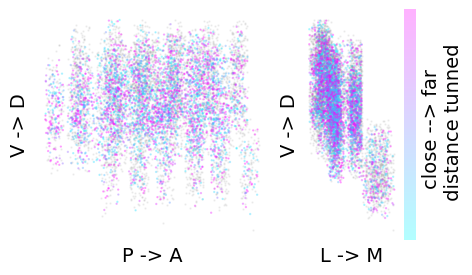

In [83]:
reload(anat_dtg)
f, axes = plt.subplots(1, 2, figsize=(5, 3), width_ratios=[2, 1])
anat_dtg.plot_anatomical_distance_tuning(anat_df, f=f, axes=axes)
f.savefig("../results/distance_to_goal/figures/supp/anatomical_distance_tuning.pdf")

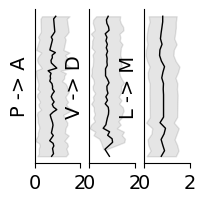

In [89]:
reload(anat_dtg)
f, axes = plt.subplots(1, 3, figsize=(2, 2), sharex=True)
anat_dtg.plot_axis_distance_tuning(anat_df, axes=axes)
f.savefig("../results/distance_to_goal/figures/supp/anatomical_distance_tuning_axes.pdf")